# **EDA Notebook Special Offer Product**



---
## 0. Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip



You can now save your data files in: /Users/shanusharma/Desktop/Python/MDSI/ML/AT3/drive-download-20260516T100846Z-3-001/36106/assignment/AT3/data


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
utstd 0.1.8 requires scikit-learn~=1.5.1, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
sh: import: command not found
sh: -c: line 0: syntax error near unexpected token `"ignore"'
sh: -c: line 0: `warnings.filterwarnings("ignore")'


---
## Student Information

In [2]:
group_name = "20"
student_name = "Shanu Sharma"
student_id = "25979360"

In [3]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [6]:
# No additional packages required for this EDA notebook.

### 0.b Import Packages

In [7]:
# Import packages used for data inspection and plotting.
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

---
## B. Data Understanding

In [8]:
# Do not modify this code
try:
  df = pd.read_csv(at.folder_path / "special_offer_product.csv")
except Exception as e:
  print(e)

### B.1 Explore Dataset

In [9]:
# Preview records and check the structure of the offer-product mapping table.
display(df.head())

print(f"Rows and columns: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate special_offer_id/product_id pairs: {df.duplicated(['special_offer_id', 'product_id']).sum()}",'\n')

print("Missing values:")
display(df.isna().sum())

print("Unique values:")
display(df.nunique())

,special_offer_id,product_id
0,a1444fcd-4b51-4227-94cf-b13c1a2a6281,8ea7e0d2-fd39-4625-9a5a-e5575f7cfcca
1,a1444fcd-4b51-4227-94cf-b13c1a2a6281,d39463ae-af40-4f64-8583-fa86deec88a9
2,a1444fcd-4b51-4227-94cf-b13c1a2a6281,05385566-38df-4855-94a8-786cae6ffe49
3,a1444fcd-4b51-4227-94cf-b13c1a2a6281,f33d8a41-b92f-4f2a-8f75-76ea2f25722b
4,a1444fcd-4b51-4227-94cf-b13c1a2a6281,26c6c52f-19c1-4760-a72d-a452f0502a1f


Rows and columns: (538, 2)
Duplicate rows: 0
Duplicate special_offer_id/product_id pairs: 0 

Missing values:


special_offer_id    0
product_id          0
dtype: int64

Unique values:


special_offer_id     15
product_id          295
dtype: int64

In [10]:
dataset_insights = """
The special_offer_product dataset contains 538 rows and 2 columns: special_offer_id and product_id. Each row represents one relationship between a special offer and a product. For the clustering analysis, this dataset is important because it shows which products are connected to promotion rules and can therefore receive promotion-exposure features.

The dataset is clean for joining because there are no missing values, no duplicate rows, and no duplicate special_offer_id/product_id pairs. It contains 15 unique special_offer_id values and 295 unique product_id values. This means it can be used as a reliable bridge between offer-level information and product-level analysis.

For the product-level clustering workflow, this table allows promotion behaviour to be converted into candidate clustering features. After joining with special_offer, the prepared dataset can describe products by no-discount exposure, volume-discount exposure, customer/reseller promotion exposure, and different levels of discount intensity. These signals may help the final clusters describe promotion dependency and possible margin pressure, but the business meaning should be confirmed after cluster profiling.
"""

In [11]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.2 Explore Feature of Interest `special_offer_id`

In [12]:
# Count how many products are linked to each special offer, then add offer details.
special_offer = pd.read_csv(at.folder_path / "special_offer.csv")

special_offer_counts = (
    df.groupby("special_offer_id")
    .size()
    .reset_index(name="num_products")
    .merge(
        special_offer[["special_offer_id", "description", "type", "category", "discount_pct"]],
        on="special_offer_id",
        how="left",
    )
    .sort_values("num_products", ascending=False)
)

display(special_offer_counts[[
    "special_offer_id",
    "description",
    "type",
    "category",
    "discount_pct",
    "num_products",
]])
display(special_offer_counts["num_products"].describe().round(2))

,special_offer_id,description,type,category,discount_pct,num_products
7,a1444fcd-4b51-4227-94cf-b13c1a2a6281,No Discount,No Discount,No Discount,0.00,295
14,df7c9acd-bc0c-4ab0-93ec-064e2b93af0d,Volume Discount 11 to 14,Volume Discount,Reseller,0.02,111
13,da53c22d-5867-4110-b1d0-8d84bea95ab5,Volume Discount 15 to 24,Volume Discount,Reseller,0.05,55
9,aec729b3-e92e-4f2c-971c-4c5d426a99b9,Volume Discount 25 to 40,Volume Discount,Reseller,0.10,17
12,c6fdf038-0e61-436b-a074-ba205a1221cc,LL Road Frame Sale,Excess Inventory,Reseller,0.35,12
10,c319131d-f166-40fe-ab38-cc2cb9f370d8,Touring-3000 Promotion,New Product,Reseller,0.15,10
11,c56f47a7-91e8-42c0-ba34-1048ceb3deb0,Mountain-100 Clearance Sale,Discontinued Product,Reseller,0.35,8
0,26e5fe80-b12f-43fe-aeb0-f8bd97970c49,Half-Price Pedal Sale,Seasonal Discount,Customer,0.50,7
2,57594a82-1a1c-497b-98dd-90e46a1c045c,Mountain-500 Silver Clearance Sale,Discontinued Product,Reseller,0.40,7
3,6468cb43-e8b4-475f-b705-f4d37f1c59eb,Touring-1000 Promotion,New Product,Reseller,0.20,4


count     15.00
mean      35.87
std       77.38
min        1.00
25%        3.00
50%        7.00
75%       14.50
max      295.00
Name: num_products, dtype: float64

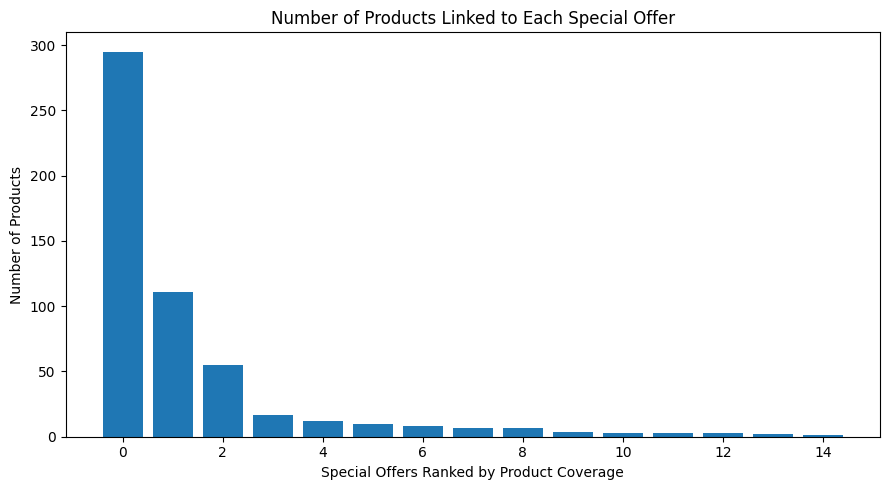

In [13]:
# Plot product coverage by special offer.
plt.figure(figsize=(9, 5))
plt.bar(range(len(special_offer_counts)), special_offer_counts["num_products"])
plt.title("Number of Products Linked to Each Special Offer")
plt.xlabel("Special Offers Ranked by Product Coverage")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

In [14]:
feature_1_insights = """
special_offer_id identifies the offer rule linked to each product. There are 15 unique offer rules in this mapping table. The largest linked offer is No Discount, which is connected to 295 products and has discount_pct equal to 0.00. Therefore, the high product count mostly reflects baseline selling coverage, not heavy promotional activity.

The actual discount exposure is better represented by the remaining offer rules with discount_pct greater than zero. The largest true discount groups are Volume Discount 11 to 14 linked to 111 products, Volume Discount 15 to 24 linked to 55 products, and Volume Discount 25 to 40 linked to 17 products. Smaller targeted offers include excess-inventory, discontinued-product, new-product, and seasonal discounts.

For final product clustering, special_offer_id should not be used as a raw identifier. Instead, it should be used to derive product-level features after joining with the special_offer table, such as num_linked_offers, num_discount_offers, has_no_discount_only, has_volume_discount, maximum discount_pct, and average discount_pct. Separating No Discount from actual discount offers is important because a product linked only to No Discount should not be treated as promotion-dependent.
"""

In [15]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### B.3 Explore Feature of Interest `product_id`

In [16]:
# Count how many special offers are linked to each product, then add product details.
product = pd.read_csv(at.folder_path / "product.csv")

# product.csv contains repeated product_id rows, so create one lookup row per product_id before joining.
product_lookup = (
    product.sort_values(["product_id", "name"], na_position="last")
    .drop_duplicates("product_id", keep="first")
)

product_offer_counts = (
    df.groupby("product_id")
    .size()
    .reset_index(name="num_offers")
    .merge(
        product_lookup[[
            "product_id",
            "name",
            "product_number",
            "color",
            "standard_cost",
            "list_price",
            "product_line",
            "class",
            "style",
        ]],
        on="product_id",
        how="left",
    )
    .sort_values(["num_offers", "name"], ascending=[False, True])
)

display(product_offer_counts[[
    "product_id",
    "name",
    "product_number",
    "color",
    "standard_cost",
    "list_price",
    "product_line",
    "class",
    "style",
    "num_offers",
]].head(20))
display(product_offer_counts["num_offers"].describe().round(2))
display(product_offer_counts["num_offers"].value_counts().sort_index())

,product_id,name,product_number,color,standard_cost,list_price,product_line,class,style,num_offers
211,aa496d61-efa1-44b6-8b6f-a05b18c3ec25,"Full-Finger Gloves, L",GL-F110-L,Black,15.6709,37.99,M,NaN,U,5
280,f33d8a41-b92f-4f2a-8f75-76ea2f25722b,"Sport-100 Helmet, Black",HL-U509,Black,13.0863,34.99,S,NaN,NaN,5
13,05385566-38df-4855-94a8-786cae6ffe49,"Sport-100 Helmet, Red",HL-U509-R,Red,13.0863,34.99,S,NaN,NaN,5
52,2c372316-0257-442e-ac56-9e7a2d7c1793,"Women's Mountain Shorts, L",SH-W890-L,Black,NaN,69.99,M,NaN,W,5
61,34ad3302-abb1-4d4d-9f75-b1c0c5919313,NaN,HL-U509-B,Blue,13.0863,34.99,S,NaN,NaN,5
64,36847649-a79a-4f70-9b5d-5c403627ab75,AWC Logo Cap,CA-1098,Multi,6.9223,8.99,S,NaN,U,4
293,ff814bac-d3da-4f66-b911-96ae92edb41a,Bike Wash - Dissolver,CL-9009,NaN,2.9733,7.95,S,NaN,NaN,4
25,0fcd0d2f-4f37-40ed-9d9e-c915482f002b,"Classic Vest, S",VE-C304-S,Blue,23.7490,63.50,S,NaN,U,4
236,c86fa47b-7abb-4704-a3a0-72672b79f306,"Full-Finger Gloves, M",NaN,Black,15.6709,37.99,M,NaN,U,4
191,9d7e34ff-9daf-4d53-a2e2-c4433ddbc8ac,Hitch Rack - 4-Bike,RA-H123,NaN,44.8800,120.00,S,NaN,NaN,4


count    295.00
mean       1.82
std        1.01
min        1.00
25%        1.00
50%        1.00
75%        2.00
max        5.00
Name: num_offers, dtype: float64

num_offers
1    148
2     79
3     45
4     18
5      5
Name: count, dtype: int64

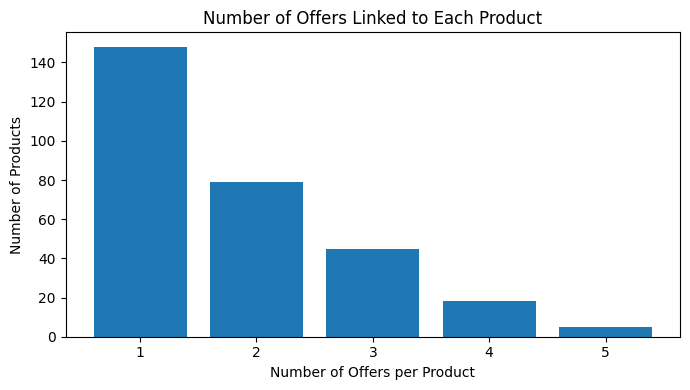

In [17]:
# Plot how many offers each product is linked to.
offer_exposure_counts = product_offer_counts["num_offers"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(offer_exposure_counts.index.astype(str), offer_exposure_counts.values)
plt.title("Number of Offers Linked to Each Product")
plt.xlabel("Number of Offers per Product")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

In [18]:
feature_2_insights = """
product_id identifies the products that are connected to special offers. The table contains 295 unique products. After joining with product details, the output shows which products have the highest linked-offer exposure where product attributes are available. Most products are linked to a small number of offers: 148 products are linked to one offer, while only 5 products are linked to five offers.

There are 55 products with missing names after joining with product.csv, but the product_id and offer relationship remain valid. Product details such as name, product_number, colour, cost, and list price are used here only to make the EDA easier to interpret. They should not replace product_id as the reliable join key.

For the retailer's margin-risk clustering problem, num_offers alone can be misleading because a product linked only to No Discount has a normal selling condition, not real promotion pressure. In the final modelling dataset, product_id should be the unit of analysis, and this table should be aggregated by product_id to create separate features such as num_linked_offers, num_discount_offers, has_discount_offer, has_volume_discount, max_discount_pct, and average_discount_pct after joining with special_offer.
"""

In [19]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.4 Grouped Analysis: Offer-Product Promotion Relationship

In [20]:
# Join with special_offer to interpret offer-product links by promotion type.
special_offer = pd.read_csv(at.folder_path / "special_offer.csv")

offer_product_detail = df.merge(
    special_offer[["special_offer_id", "description", "discount_pct", "type", "category"]],
    on="special_offer_id",
    how="left",
)

display(offer_product_detail.head())
display(offer_product_detail["type"].value_counts())
display(offer_product_detail.groupby("type")["product_id"].nunique().sort_values(ascending=False))

,special_offer_id,product_id,description,discount_pct,type,category
0,a1444fcd-4b51-4227-94cf-b13c1a2a6281,8ea7e0d2-fd39-4625-9a5a-e5575f7cfcca,No Discount,0.0,No Discount,No Discount
1,a1444fcd-4b51-4227-94cf-b13c1a2a6281,d39463ae-af40-4f64-8583-fa86deec88a9,No Discount,0.0,No Discount,No Discount
2,a1444fcd-4b51-4227-94cf-b13c1a2a6281,05385566-38df-4855-94a8-786cae6ffe49,No Discount,0.0,No Discount,No Discount
3,a1444fcd-4b51-4227-94cf-b13c1a2a6281,f33d8a41-b92f-4f2a-8f75-76ea2f25722b,No Discount,0.0,No Discount,No Discount
4,a1444fcd-4b51-4227-94cf-b13c1a2a6281,26c6c52f-19c1-4760-a72d-a452f0502a1f,No Discount,0.0,No Discount,No Discount


type
No Discount             295
Volume Discount         185
Excess Inventory         16
Discontinued Product     15
New Product              14
Seasonal Discount        13
Name: count, dtype: int64

type
No Discount             295
Volume Discount         112
Excess Inventory         16
Discontinued Product     15
New Product              14
Seasonal Discount        10
Name: product_id, dtype: int64

,special_offer_id,description,discount_pct,type,category
5,aec8118d-8c09-4aa9-94f1-e83b9ce8ed96,Volume Discount over 60,0.2,Volume Discount,Reseller


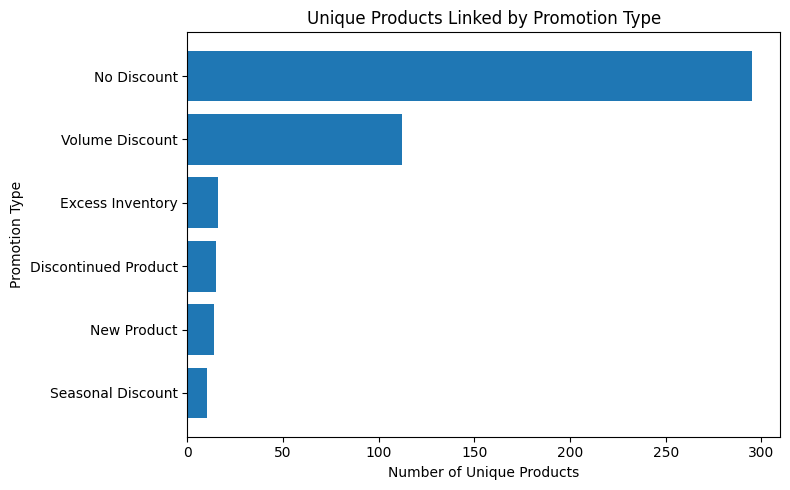

In [21]:
# Check whether any offers from special_offer are not linked to products.
unmapped_offers = special_offer.loc[
    ~special_offer["special_offer_id"].isin(df["special_offer_id"]),
    ["special_offer_id", "description", "discount_pct", "type", "category"],
]

display(unmapped_offers)

# Plot product links by promotion type.
type_product_counts = offer_product_detail.groupby("type")["product_id"].nunique().sort_values()

plt.figure(figsize=(8, 5))
plt.barh(type_product_counts.index, type_product_counts.values)
plt.title("Unique Products Linked by Promotion Type")
plt.xlabel("Number of Unique Products")
plt.ylabel("Promotion Type")
plt.tight_layout()
plt.show()

In [22]:
group_analysis_insights = """
The grouped analysis shows how the bridge table can turn offer-product links into interpretable promotion-exposure signals. When joined with special_offer, the largest number of product links comes from No Discount and Volume Discount offers, while more targeted promotion types such as discontinued-product or clearance-related offers, seasonal offers, new-product promotions, and excess-inventory offers are linked to fewer products.

No Discount should be treated as baseline selling exposure, not promotional pressure. This distinction matters because final product-level features should separate baseline no-discount exposure from actual discount exposure, volume discount exposure, and maximum or average discount percentage. Otherwise, products with only No Discount could be incorrectly interpreted as promotion-dependent.

One special offer from the special_offer table is not present in this mapping table: Volume Discount over 60. This means it exists as an offer rule, but no products are linked to it in special_offer_product. This should be noted during preparation so the final modelling table does not assume every offer definition is active for products.

The bridge table contains 295 unique products, which is more than the 254 sales-active products identified in sales_order_detail. The extra products exist in the offer-product mapping but have no sales order history, meaning they were linked to offers but never sold in the observed transaction period. In the preparation step, the 254 sales-active products define the modelling population, and the bridge table is filtered to that set rather than the full 295.

For the final clustering solution, this dataset provides the join path needed to convert offer-level business information into product-level features. This supports the selected margin-risk business use case because the retailer needs product segments that describe promotion strategy, discount exposure, and product behaviour, not just technical IDs, price, cost, or sales performance.
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='group_analysis_insights', value=group_analysis_insights)